In [1]:
import numpy as np
import scipy.stats as ss
import scipy as sp
import matplotlib.pyplot as plt 
import time
import math

# Task 1

(array([ 65.,  91., 120., 108., 108.,  98.,  84.,  79.,  53.,  39.,  33.,
         34.,  22.,  12.,  12.,  13.,   6.,  10.,   5.,   0.,   4.,   0.,
          1.,   1.,   0.,   0.,   1.,   0.,   0.,   1.]),
 array([   3. ,   44.9,   86.8,  128.7,  170.6,  212.5,  254.4,  296.3,
         338.2,  380.1,  422. ,  463.9,  505.8,  547.7,  589.6,  631.5,
         673.4,  715.3,  757.2,  799.1,  841. ,  882.9,  924.8,  966.7,
        1008.6, 1050.5, 1092.4, 1134.3, 1176.2, 1218.1, 1260. ]),
 <BarContainer object of 30 artists>)

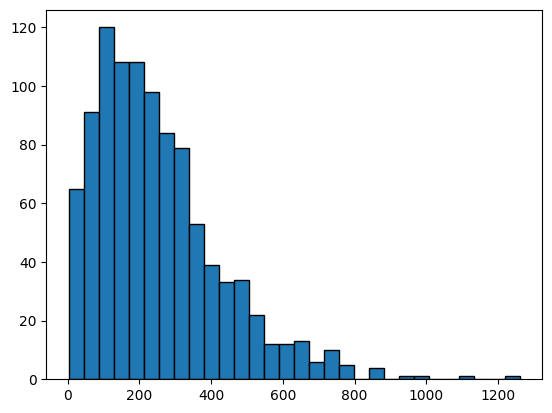

In [2]:
P = np.array([
    [0.9915, 0.005,  0.0025, 0.000, 0.001],
    [0.000,  0.986,  0.005,  0.004, 0.005],
    [0.000,  0.000,  0.992,  0.003, 0.005],
    [0.000,  0.000,  0.000,  0.991, 0.009],
    [0.000,  0.000,  0.000,  0.000, 1.000],])

rng  = np.random.default_rng(30)
N    = 1000
                

lifetimes = np.empty(N)
visited   = np.zeros((N, 5), bool)

for w in range(N):
    s = 0                          
    t = 0
    visited[w,s] = True
    while s != 4: # 4 = death
        s = rng.choice(5, p=P[s]) 
        t += 1
        visited[w,s] = True
    lifetimes[w] = t            

plt.hist(lifetimes,bins=30, edgecolor="black")

In [3]:
np.sum(visited[:,1])/N

np.float64(0.573)

# task 2 

In [4]:


N    = 1000
t  = 120

states = np.arange(0,5)

p_0 = np.array([1,0,0,0,0])



p_real = p_0@np.linalg.matrix_power(P,t)

#states

In [5]:
rng  = np.random.default_rng(30)
lifetimes = np.empty(N)
last_state =np.zeros(N,dtype=int)
for w in range(N):
    s = 0                          
    t = 0
    while s != 4: # 4 = dø
        s = rng.choice(5, p=P[s]) 
        t += 1
        last_state[w] = s
        if t >= 120:
            break
    lifetimes[w] = t            

bincount = np.bincount(last_state, minlength=5)

p_estimate = bincount/N

<BarContainer object of 5 artists>

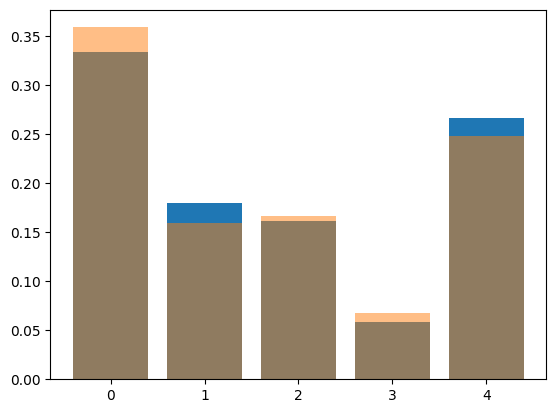

In [6]:
plt.bar(states,p_estimate)
plt.bar(states,p_real,alpha = 0.5)

In [7]:
bincount

array([334, 180, 161,  58, 267])

In [8]:
ss.chisquare(bincount,p_real*N)

Power_divergenceResult(statistic=np.float64(7.51282134507163), pvalue=np.float64(0.11114525282277521))

# task 3

In [9]:
P_s = np.delete(P, -1, 0)  
P_s = np.delete(P_s, -1, 1) 

p_0 = np.array([1,0,0,0])
E =np.sum(p_0@np.linalg.inv(np.eye(4)-P_s))
E

p_s = P[:-1,-1]

dist = lambda t: p_0@np.linalg.matrix_power(P_s,t)@p_s
dist(120)


np.float64(0.002593914399220477)

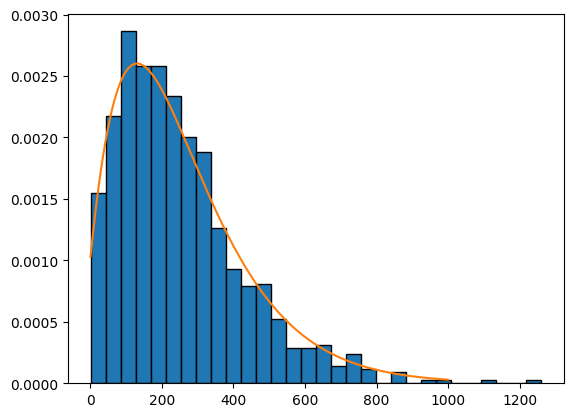

In [10]:
P = np.array([
    [0.9915, 0.005,  0.0025, 0.000, 0.001],
    [0.000,  0.986,  0.005,  0.004, 0.005],
    [0.000,  0.000,  0.992,  0.003, 0.005],
    [0.000,  0.000,  0.000,  0.991, 0.009],
    [0.000,  0.000,  0.000,  0.000, 1.000],])

rng  = np.random.default_rng(30)
N    = 1000
                

lifetimes = np.empty(N)
visited   = np.zeros((N, 5), bool)

for w in range(N):
    s = 0                          
    t = 0
    visited[w,s] = True
    while s != 4: # 4 = death
        s = rng.choice(5, p=P[s]) 
        t += 1
        visited[w,s] = True
    lifetimes[w] = t            

ts  = np.arange(1, 1000)
pmf = np.array([dist(t) for t in ts])

plt.hist(lifetimes, bins=30, density=True, edgecolor="black")
plt.plot(ts, pmf)

In [11]:
dist(1)*1000

np.float64(1.0290000000000001)

# task 4

In [12]:
rng    = np.random.default_rng(30)
target = 1000
lifetimes = []

while len(lifetimes) < target:
    s, t, recur12 = 0, 0, False
    while s != 4:                      
        s = rng.choice(5, p=P[s])
        t += 1
        if t <= 12 and s in (1, 2):    
            recur12 = True
    if recur12 and t > 12:             
        lifetimes.append(t)

np.mean(lifetimes)


np.float64(171.09)

# task 5

In [13]:
iterations = 100
rng  = np.random.default_rng(30)
fractions = np.zeros(iterations)
means = np.zeros_like(fractions)
for _ in range(iterations):
    N = 200
    lifetimes = np.empty(N)
    visited   = np.zeros((N, 5), bool)

    for w in range(N):
        s = 0                          
        t = 0
        visited[w,s] = True
        while s != 4: # 4 = death
            s = rng.choice(5, p=P[s]) 
            t += 1
            visited[w,s] = True
        lifetimes[w] = t
    means[_] = np.mean(lifetimes)        
    fractions[_]= np.mean(lifetimes < 350) 

In [14]:
np.mean(fractions),np.var(fractions,ddof= 1)

(np.float64(0.7372499999999998), np.float64(0.0010673611111111122))

In [15]:
X= fractions
Z = means
mu_Z = E
cov = np.cov(X, Z)            
c   = -cov[0,1] / cov[1,1]
Y   = X + c*(Z - mu_Z)

np.mean(Y),np.var(Y,ddof = 1)

(np.float64(0.7371295317090832), np.float64(0.0003515077233186783))

# part 2

# task 7

In [16]:
Q = np.array([
    [-0.0085,  0.005,  0.0025,  0.000,  0.001],
    [ 0.000,  -0.014,  0.005,   0.004,  0.005],
    [ 0.000,   0.000, -0.008,   0.003,  0.005],
    [ 0.000,   0.000,  0.000,  -0.009,  0.009],
    [ 0.000,   0.000,  0.000,   0.000,  0.000],
])

In [17]:

rng     = np.random.default_rng(30)
N       = 1000        

lifetimes = np.zeros(N)

reappered = np.zeros(N)


for w in range(N):
    s, t = 0, 0.0                  
    while s != 4:
        rate = -Q[s, s]
        t += rng.exponential(1/rate)        
        p = Q[s].copy()
        p[s] = 0        
        p = p / rate 
        s = rng.choice(len(Q), p=p)
        if t >= 30.5 and(s==2):
            reappered[w] = True
    lifetimes[w] = t


#plt.hist(lifetimes, bins=30, edgecolor="black")
np.var(lifetimes)

np.float64(33289.148592512014)

In [18]:
np.mean(reappered)

np.float64(0.43)

In [19]:
Q_s = np.delete(Q, -1, 0)  
q_s = np.delete(Q_s, -1, 1) 


C:\Users\fedtm\AppData\Local\Temp\ipykernel_31820\2126141912.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


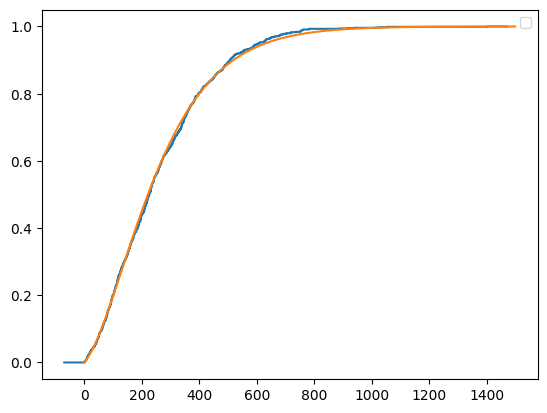

In [20]:
p_0 = np.array([1,0,0,0])
CDF = lambda t: 1 - np.sum(p_0 @ sp.linalg.expm(q_s*t))

ts = np.arange(0,1500)
res = ss.ecdf(lifetimes)
res.cdf.plot()          
plt.plot(ts, [CDF(t) for t in ts])
plt.legend()

# task 9

In [21]:
Q = np.array([
    [-0.00475, 0.0025, 0.00125, 0.000, 0.001],
    [ 0.000,  -0.007,  0.000,   0.002, 0.005],
    [ 0.000,   0.000, -0.008,   0.003, 0.005],
    [ 0.000,   0.000,  0.000,  -0.009, 0.009],
    [ 0.000,   0.000,  0.000,   0.000, 0.000],
])


In [22]:

rng     = np.random.default_rng(30)
N       = 1000        

lifetimes_treatment = np.zeros(N)

for w in range(N):
    s, t = 0, 0.0                  
    while s != 4:
        rate = -Q[s, s]
        t += rng.exponential(1/rate)        
        p = Q[s].copy()
        p[s] = 0        
        p = p / rate 
        s = rng.choice(len(Q), p=p)
    lifetimes_treatment[w] = t

np.mean(lifetimes_treatment),np.mean(lifetimes)

(np.float64(339.7750489830864), np.float64(260.6557758370406))

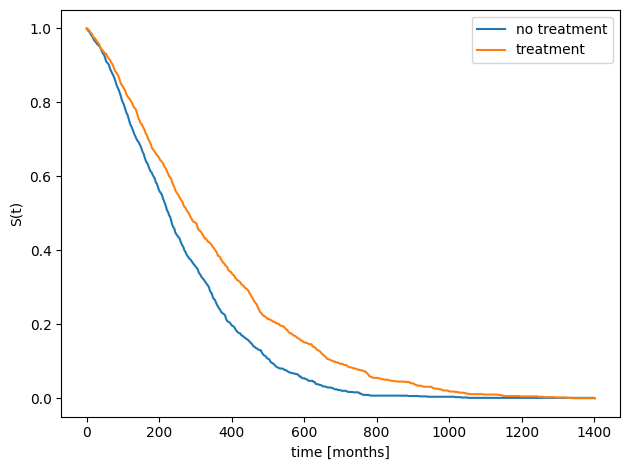

In [23]:
d_old = lambda t: np.sum(lifetimes <= t)
d_treatment = lambda t: np.sum(lifetimes_treatment <= t)

S_old = lambda t: (N - d_old(t)) / N
S_treatment = lambda t: (N - d_treatment(t)) / N

ts = np.linspace(0, max(lifetimes.max(), lifetimes_treatment.max()), 500)

plt.plot(ts, [S_old(t)       for t in ts], label="no treatment")
plt.plot(ts, [S_treatment(t) for t in ts], label="treatment")
plt.xlabel("time [months]"); plt.ylabel("S(t)")
plt.legend()
plt.tight_layout()

# task  12

In [37]:

rng     = np.random.default_rng(30)
N       = 1000        
dt = 48


next_time = 0.0

Y =  []
lifetimes_treatment = np.zeros(N)
for w in range(N):
    s, t = 0, 0.0
    next_time = 0
    obs  = []                  
    while s != 4:
        rate = -Q[s, s]
        t += rng.exponential(1/rate)
        while next_time < t:
            obs.append(s) 
            next_time += dt     
        p = Q[s].copy()
        p[s] = 0        
        p = p / rate 
        s = rng.choice(len(Q), p=p)
    lifetimes_treatment[w] = t

    obs.append(s)
    
    Y.append(np.array(obs)+1)
    
Y[0],lifetimes_treatment[0]

(array([1, 1, 1, 1, 2, 5]), np.float64(195.90922229555864))

# task 13

In [38]:
dt = 48

def one_sim_one_woman(start, end, Q, rng):
    n = len(Q)
    while True:                          
        s, t = start, 0.0
        N = np.zeros((n, n))
        S = np.zeros(n) # 5 states 
        while True: 
            rate = -Q[s, s]
            if rate == 0: # Chatten forslog det her, forstår ikke hvorfor
                S[s] += 48 - t
                break
            jump = rng.exponential(1/rate)
            if t + jump >= 48: # nu er du forbi end_time            
                S[s] += 48 - t
                break
            S[s] += jump # This women is in state s for next time
            t += jump
            p = Q[s].copy()
            p[s] = 0 
            p /= rate
            s_new = rng.choice(n, p=p)
            N[s, s_new] += 1
            s = s_new
        if s == end:                  
            return N, S

In [ ]:

Q = np.array([
    [-0.00475, 0.0025, 0.00125, 0.000, 0.001],
    [ 0.000,  -0.007,  0.000,   0.002, 0.005],
    [ 0.000,   0.000, -0.008,   0.003, 0.005],
    [ 0.000,   0.000,  0.000,  -0.009, 0.009],
    [ 0.000,   0.000,  0.000,   0.000, 0.000],
])

n = len(Q)                       # not len(Q) — Q isn't defined yet here
Q = Q * 0.9                      # initial guess

for it in range(1000):
    N_tot = np.zeros((n, n))       # reset every pass
    S_tot = np.zeros(n)
    for obs in Y:                  # E-step: all bridges under the CURRENT fixed Q
        path = obs - 1
        for k in range(len(path) - 1):
            N, S = one_sim_one_woman(path[k], path[k+1], Q, rng)
            N_tot += N
            S_tot += S
    Q = N_tot / S_tot[:, None]     # M-step: one update per full sweep
    np.fill_diagonal(Q, -Q.sum(axis=1))